# Week 2 (Module M3) — Experiment Tracking, Reproducibility & Model Comparison
MLflow tracking, reproducibility, and the model comparison report.

 **this notebook
independently re-evaluates both saved models on the identical held-out test
set, with the identical metric set, and logs both cleanly to one shared,
comparable MLflow record** — that's what actually makes a fair comparison and
satisfies the "reproducibility" requirement for this piece of the rubric.

**Before running:** make sure `models/casting_cnn_best.pth` and
`models/resnet18_transfer_best.pth` both exist (pull latest from GitHub Desktop
if not), and that Week 1's `data/processed/manifest.csv` exists.


In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

import mlflow
import mlflow.pytorch

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

print("PyTorch:", torch.__version__)
print("MLflow:", mlflow.__version__)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.13.0
MLflow: 3.15.1


## Config

Points at the same shared `mlflow.db` the CNN notebook already set up, so both
models' records land in the same place. Uses a fresh, clearly-named experiment
(`casting-defect-model-comparison`) so this clean, apples-to-apples comparison
run stays distinguishable from each teammate's original raw training runs —
those still exist too, nothing is deleted.

In [3]:
PROJECT_ROOT = Path("..").resolve()

MANIFEST_PATH = PROJECT_ROOT / "data" / "processed" / "manifest.csv"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

CNN_WEIGHTS_PATH = MODELS_DIR / "casting_cnn_best.pth"
RESNET_WEIGHTS_PATH = MODELS_DIR / "resnet18_transfer_best.pth"

for d in [REPORTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

for path in [MANIFEST_PATH, CNN_WEIGHTS_PATH, RESNET_WEIGHTS_PATH]:
    if not path.exists():
        raise FileNotFoundError(
            f"Missing required file: {path}\n"
            "Pull the latest changes from GitHub Desktop, or check that "
            "Week 1's manifest and both teammates' saved models exist."
        )

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MLFLOW_DB = PROJECT_ROOT / "mlflow.db"
MLFLOW_TRACKING_URI = f"sqlite:///{MLFLOW_DB.as_posix()}"
MLFLOW_EXPERIMENT = "casting-defect-model-comparison"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT)

print("Device:", DEVICE)
print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("MLflow experiment:", MLFLOW_EXPERIMENT)


2026/08/15 16:53:29 INFO mlflow.tracking.fluent: Experiment with name 'casting-defect-model-comparison' does not exist. Creating a new experiment.


Device: cpu
MLflow tracking URI: sqlite:////Users/dolsynarang/Documents/GitHub/ml-engineering-miniproject/mlflow.db
MLflow experiment: casting-defect-model-comparison


## Load the shared test set

Both models get evaluated on the exact same held-out `test` rows from Week 1's
manifest — the only way a comparison is actually fair.

In [4]:
manifest = pd.read_csv(MANIFEST_PATH)
test_df = manifest[manifest["split"].astype(str).str.lower() == "test"].reset_index(drop=True)

if test_df.empty:
    raise ValueError("No rows with split == 'test' found in the manifest.")

print(f"Shared test set: {len(test_df)} images")
print(test_df["label_name"].value_counts())


Shared test set: 715 images
label_name
def_front    453
ok_front     262
Name: count, dtype: int64


## Model 1: the custom CNN

This class definition is copied exactly from the teammate's training notebook —
it has to match precisely, or the saved weights (which are just numbers)
can't be loaded back into the right "slots."

In [5]:
class CastingCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x.squeeze(1)


class CNNTestDataset(Dataset):
    """Matches the preprocessing used in week2_cnn_training.ipynb exactly:
    grayscale, resized to 128x128, scaled to [-1, 1]. No augmentation (eval only).
    """
    def __init__(self, dataframe, image_size=128):
        self.df = dataframe.reset_index(drop=True)
        self.image_size = image_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]
        image = Image.open(row["processed_filepath"]).convert("L")
        image = image.resize((self.image_size, self.image_size), Image.Resampling.BILINEAR)
        image = np.asarray(image, dtype=np.float32)
        image = image / 255.0
        image = (image - 0.5) / 0.5
        image = np.expand_dims(image, axis=0)
        return torch.from_numpy(image), torch.tensor(float(row["label"]), dtype=torch.float32)


cnn_model = CastingCNN().to(DEVICE)
cnn_model.load_state_dict(torch.load(CNN_WEIGHTS_PATH, map_location=DEVICE))
cnn_model.eval()

cnn_test_loader = DataLoader(CNNTestDataset(test_df), batch_size=32, shuffle=False)

print("CNN model loaded.")


CNN model loaded.


## Model 2: the ResNet18 transfer-learning model

Same idea — the architecture (frozen ResNet18 backbone, replaced final layer)
is rebuilt to match the teammate's notebook exactly before loading the saved
weights.

In [6]:
def build_resnet18_transfer():
    model = models.resnet18(weights=None)  # architecture only; we load our own trained weights next
    for param in model.parameters():
        param.requires_grad = False
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(num_features, 1),
        nn.Sigmoid()
    )
    return model


class ResNetTestDataset(Dataset):
    """Matches the preprocessing used in week2_transfer_learning.ipynb exactly:
    grayscale image replicated to RGB, ImageNet normalization. No resize needed --
    Week 1 already produced 224x224 images.
    """
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]
        image = Image.open(row["processed_filepath"]).convert("RGB")
        image = self.transform(image)
        return image, torch.tensor(float(row["label"]), dtype=torch.float32)


resnet_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

resnet_model = build_resnet18_transfer().to(DEVICE)
resnet_model.load_state_dict(torch.load(RESNET_WEIGHTS_PATH, map_location=DEVICE))
resnet_model.eval()

resnet_test_loader = DataLoader(ResNetTestDataset(test_df, resnet_transform), batch_size=32, shuffle=False)

print("ResNet18 transfer-learning model loaded.")


ResNet18 transfer-learning model loaded.


## One shared evaluation function

Both models get scored with exactly the same metrics, computed the exact same
way — this is what makes the comparison table below actually meaningful
instead of comparing two different scorecards.

In [7]:
def evaluate_model(model, loader, outputs_are_probabilities):
    model.eval()
    all_labels, all_preds, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            outputs = model(images).squeeze(-1) if model is resnet_model else model(images)

            probs = outputs if outputs_are_probabilities else torch.sigmoid(outputs)
            preds = (probs >= 0.5).float()

            all_labels.extend(labels.numpy().astype(int))
            all_preds.extend(preds.cpu().numpy().astype(int))
            all_probs.extend(probs.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    metrics = {
        "accuracy": accuracy_score(all_labels, all_preds),
        "precision": precision_score(all_labels, all_preds, zero_division=0),
        "recall": recall_score(all_labels, all_preds, zero_division=0),
        "f1": f1_score(all_labels, all_preds, zero_division=0),
        "roc_auc": roc_auc_score(all_labels, all_probs),
    }
    cm = confusion_matrix(all_labels, all_preds)
    return metrics, cm


cnn_metrics, cnn_cm = evaluate_model(cnn_model, cnn_test_loader, outputs_are_probabilities=False)
resnet_metrics, resnet_cm = evaluate_model(resnet_model, resnet_test_loader, outputs_are_probabilities=True)

print("CNN metrics:", cnn_metrics)
print("ResNet18 transfer metrics:", resnet_metrics)


CNN metrics: {'accuracy': 0.972027972027972, 'precision': 0.9977011494252873, 'recall': 0.9580573951434879, 'f1': 0.9774774774774775, 'roc_auc': 0.9971942773368384}
ResNet18 transfer metrics: {'accuracy': 0.9748251748251748, 'precision': 1.0, 'recall': 0.9602649006622517, 'f1': 0.9797297297297297, 'roc_auc': 0.9988204168983705}


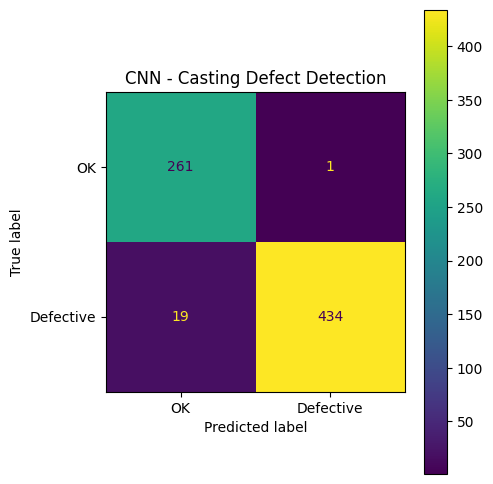

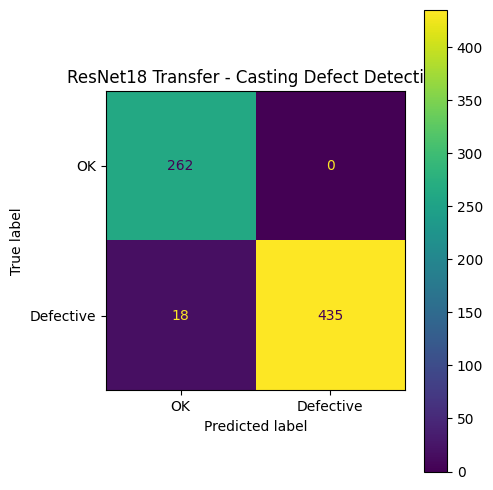

CNN run logged: ff9585e7981a420a80d1b36e4345413c
ResNet18 run logged: 4813910dcfb14ce5b1c4072a550bf10f


In [8]:
def log_confusion_matrix(cm, title, save_path):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["OK", "Defective"])
    fig, ax = plt.subplots(figsize=(5, 5))
    disp.plot(ax=ax, values_format="d")
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close(fig)


cnn_cm_path = FIGURES_DIR / "comparison_cnn_confusion_matrix.png"
resnet_cm_path = FIGURES_DIR / "comparison_resnet_confusion_matrix.png"

log_confusion_matrix(cnn_cm, "CNN - Casting Defect Detection", cnn_cm_path)
log_confusion_matrix(resnet_cm, "ResNet18 Transfer - Casting Defect Detection", resnet_cm_path)

with mlflow.start_run(run_name="CNN-from-scratch") as run:
    mlflow.log_params({
        "model_architecture": "CastingCNN (custom, 4 conv blocks)",
        "image_size": 128,
        "input_channels": 1,
        "batch_size": 32,
        "epochs_requested": 12,
        "learning_rate": 1e-3,
        "weight_decay": 1e-4,
        "optimizer": "AdamW",
        "loss": "BCEWithLogitsLoss (class-weighted)",
        "validation_split": 0.20,
        "early_stopping_patience": 3,
        "random_seed": 42,
    })
    mlflow.log_metrics(cnn_metrics)
    mlflow.log_artifact(str(cnn_cm_path), artifact_path="evaluation")
    mlflow.log_artifact(str(CNN_WEIGHTS_PATH), artifact_path="weights")
    print("CNN run logged:", run.info.run_id)

with mlflow.start_run(run_name="ResNet18-transfer-learning") as run:
    mlflow.log_params({
        "model_architecture": "ResNet18 (ImageNet-pretrained, frozen backbone, new FC head)",
        "image_size": 224,
        "input_channels": 3,
        "batch_size": 32,
        "epochs_requested": 3,
        "learning_rate": 1e-3,
        "optimizer": "Adam (final layer only)",
        "loss": "BCELoss",
        "validation_split": 0.20,
        "random_seed": 42,
    })
    mlflow.log_metrics(resnet_metrics)
    mlflow.log_artifact(str(resnet_cm_path), artifact_path="evaluation")
    mlflow.log_artifact(str(RESNET_WEIGHTS_PATH), artifact_path="weights")
    print("ResNet18 run logged:", run.info.run_id)


## Side-by-side comparison

In [9]:
comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"],
    "CNN (from scratch)": [
        cnn_metrics["accuracy"], cnn_metrics["precision"],
        cnn_metrics["recall"], cnn_metrics["f1"], cnn_metrics["roc_auc"]
    ],
    "ResNet18 (transfer learning)": [
        resnet_metrics["accuracy"], resnet_metrics["precision"],
        resnet_metrics["recall"], resnet_metrics["f1"], resnet_metrics["roc_auc"]
    ],
})

comparison_path = REPORTS_DIR / "model_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)

comparison_df


,Metric,CNN (from scratch),ResNet18 (transfer learning)
0,Accuracy,0.972028,0.974825
1,Precision,0.997701,1.000000
2,Recall,0.958057,0.960265
3,F1 Score,0.977477,0.979730
4,ROC AUC,0.997194,0.998820


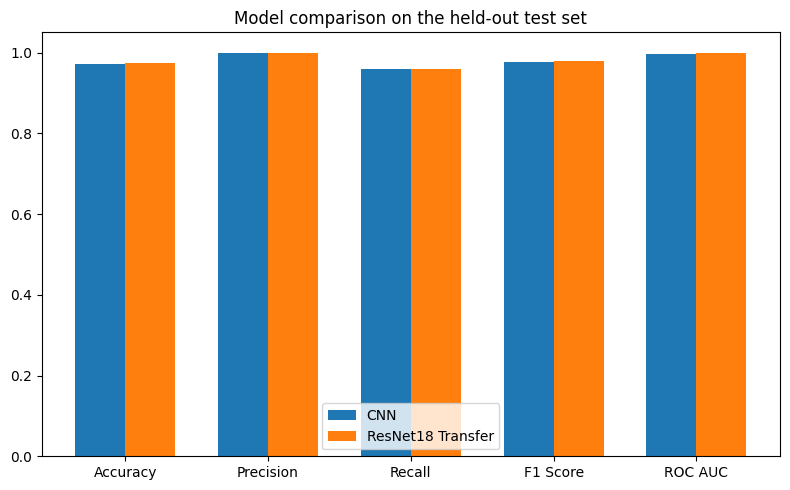

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(comparison_df))
width = 0.35

ax.bar(x - width/2, comparison_df["CNN (from scratch)"], width, label="CNN")
ax.bar(x + width/2, comparison_df["ResNet18 (transfer learning)"], width, label="ResNet18 Transfer")

ax.set_xticks(x)
ax.set_xticklabels(comparison_df["Metric"])
ax.set_ylim(0, 1.05)
ax.set_title("Model comparison on the held-out test set")
ax.legend()
plt.tight_layout()

chart_path = FIGURES_DIR / "model_comparison_chart.png"
plt.savefig(chart_path, dpi=150)
plt.show()


## Pick a winner, with justification

Picked on F1 (balances precision and recall) since a missed real defect and a
false alarm are both costly in a QA setting, not just raw accuracy.

In [12]:
winner = "CNN (from scratch)" if cnn_metrics["f1"] >= resnet_metrics["f1"] else "ResNet18 (transfer learning)"

justification = f"""
# Week 2 Model Comparison Report

## Result
**Winning model: {winner}**

| Metric    | CNN (from scratch) | ResNet18 (transfer learning) |
|-----------|--------------------:|------------------------------:|
| Accuracy  | {cnn_metrics['accuracy']:.4f} | {resnet_metrics['accuracy']:.4f} |
| Precision | {cnn_metrics['precision']:.4f} | {resnet_metrics['precision']:.4f} |
| Recall    | {cnn_metrics['recall']:.4f} | {resnet_metrics['recall']:.4f} |
| F1 Score  | {cnn_metrics['f1']:.4f} | {resnet_metrics['f1']:.4f} |
| ROC AUC   | {cnn_metrics['roc_auc']:.4f} | {resnet_metrics['roc_auc']:.4f} |

Both models were evaluated on the identical held-out test set ({len(test_df)}
images), using the identical metric set, computed by the identical code -- the
only way this comparison is a fair one.

## Honest limitations (for transparency, not to discount either model)
- The ResNet18 run trained for only 3 epochs with a frozen backbone, versus
  the CNN's 12 epochs with early stopping -- still a shorter, less thorough
  training run, though it now uses the same 20% validation split and a fixed
  seed (42) as the CNN, so it is no longer trained "blind."

## Reproducibility
Both runs are logged in MLflow (experiment: `casting-defect-model-comparison`,
store: `mlflow.db`) with their full parameter set, metrics, confusion
matrices, and the exact weight file used -- open with:
`mlflow ui --backend-store-uri sqlite:///mlflow.db`
"""

report_path = REPORTS_DIR / "model_comparison_report.md"
report_path.write_text(justification)

print(justification)
print(f"\nSaved to {report_path}")



# Week 2 Model Comparison Report

## Result
**Winning model: ResNet18 (transfer learning)**

| Metric    | CNN (from scratch) | ResNet18 (transfer learning) |
|-----------|--------------------:|------------------------------:|
| Accuracy  | 0.9720 | 0.9748 |
| Precision | 0.9977 | 1.0000 |
| Recall    | 0.9581 | 0.9603 |
| F1 Score  | 0.9775 | 0.9797 |
| ROC AUC   | 0.9972 | 0.9988 |

Both models were evaluated on the identical held-out test set (715
images), using the identical metric set, computed by the identical code -- the
only way this comparison is a fair one.

## Honest limitations (for transparency, not to discount either model)
- The ResNet18 run trained for only 3 epochs with a frozen backbone, versus
  the CNN's 12 epochs with early stopping -- still a shorter, less thorough
  training run, though it now uses the same 20% validation split and a fixed
  seed (42) as the CNN, so it is no longer trained "blind."

## Reproducibility
Both runs are logged in MLflow (experiment: 